<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%204%20/%20Econ_5200_Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip -q install category_encoders

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
omnicare_clinical = pd.read_csv("OmniCare_Clinical_Vitals.csv")
omnicare_telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")

In [7]:
omnicare_clinical

,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0
...,...,...,...,...,...,...
4995,5995,169.3,72.7,25.39,106.0,76.0
4996,5996,180.7,56.6,17.34,139.0,100.0
4997,5997,216.7,99.4,21.16,140.0,96.0
4998,5998,182.1,77.9,23.48,107.0,83.0


In [8]:
omnicare_clinical.shape

(5000, 6)

In [9]:
omnicare_clinical.isna().sum()

,0
Patient_ID,0
Height_cm,0
Weight_kg,0
BMI,0
Systolic_BP,0
Diastolic_BP,0


In [10]:
omnicare_telemetry

,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34
...,...,...,...,...,...,...,...,...
4995,5995,1,0.140,52.2,M96.598,0.58,3.7,1150.29
4996,5996,0,0.152,76.0,M63.490,0.68,17.6,1739.46
4997,5997,0,0.363,91.0,C64.505,0.77,2.3,1713.14
4998,5998,0,0.118,53.5,A23.926,0.55,9.2,1589.11


In [11]:
omnicare_telemetry.shape

(5000, 8)

In [12]:
omnicare_telemetry.isna().sum()

,0
Patient_ID,0
High_Deductible_Insurance_Plan,0
Inpatient_Admission_Rate,0
Continuous_Heart_Rate,1214
Primary_Diagnosis_Code,0
Clinic_Capacity_Percentage,0
Time_of_Day_Index,0
Procedure_Cost_USD,0


# Phase 1

## Step 1.1

Ans: The omitted confounder indicate the factor that is likely related and affect the cause and effect while did not include in the model. According to this specific situation, the omitted confounder might be any factors that related to the social power of the one in the society. For instance, the social power of the one including factors like the wealth they hold and poverty condition. To be specific, the power of the one factor like poverty could affect patients to chose high deductible insurance due to the lower price or they are more likly to be hospitalized(in this case related to Inpatient Admission Rate) since less accessible to to medical related service. While the one with higher wealth status would lead to the result in a opposite way. In other words, the social power factor would affect both "inpatient admission rate" and "high deductible insurance plan." The correlation between each variables would lead to the false explanation of the causal relationship. Therefore, if not controlling such factors, it might lead to biased coefficient.



The DAG would be:

The social power of the one (Poverty and wealth) -> Inpatient Admission Rate

The social power of the one (Poverty and wealth) -> High Deductible Insurance Plan



Therefore, if not controlling such confounder factors, the bias would be absorbed and the true causality effect might not be shown due to high deductible insurance factor includes omitted variable bias of social power. Eventually, the true impact and causality effect from insurance type to "inpatient admission rate" could not be explained due to such correlation by the common cause.

## Step 1.2

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [14]:
def calc_vif(X_df):
  vif_df = pd.DataFrame({
      "feature": X_df.columns,
      'vif': [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
  })
  return vif_df.sort_values("vif", ascending=False).reset_index(drop=True)

In [15]:
vif_x = omnicare_clinical[["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]].copy()

In [16]:
vif_x_constant = sm.add_constant(vif_x, has_constant="add" )


In [17]:
the_initial_vif = calc_vif(vif_x_constant)

In [18]:
the_initial_vif

,feature,vif
0,const,3369.565806
1,Weight_kg,57.428058
2,Height_cm,28.419446
3,BMI,16.981232
4,Diastolic_BP,4.219820
5,Systolic_BP,4.219406


Ans: Weigh_kg has the vif of 57.43, which is the most redundant value. There are three variables exceed the value of 10 totally, which are Weight_kg, Height_cm, and BMI. Such patterns show the condition of multicollinearity, and ranked by Weight_kg>Height_cm>BMI.

In [19]:
drop_redudant_vif_x = vif_x.drop(columns=["Weight_kg"])

In [20]:
drop_redudant_vif_x_constant = sm.add_constant(drop_redudant_vif_x, has_constant="add")

In [21]:
final_vif = calc_vif(drop_redudant_vif_x_constant)
final_vif

,feature,vif
0,const,210.878580
1,Diastolic_BP,4.219757
2,Systolic_BP,4.219385
3,BMI,1.112989
4,Height_cm,1.112811


Ans: After dropping the most redundant value of Weight_kg, the final_vif table shows a significant improvement in the stableness of the structure. To be specific, vif for BMI and Height_cm are less than 10 after the dropping of Weight_kg (The most redundant variable).

# Phase 2

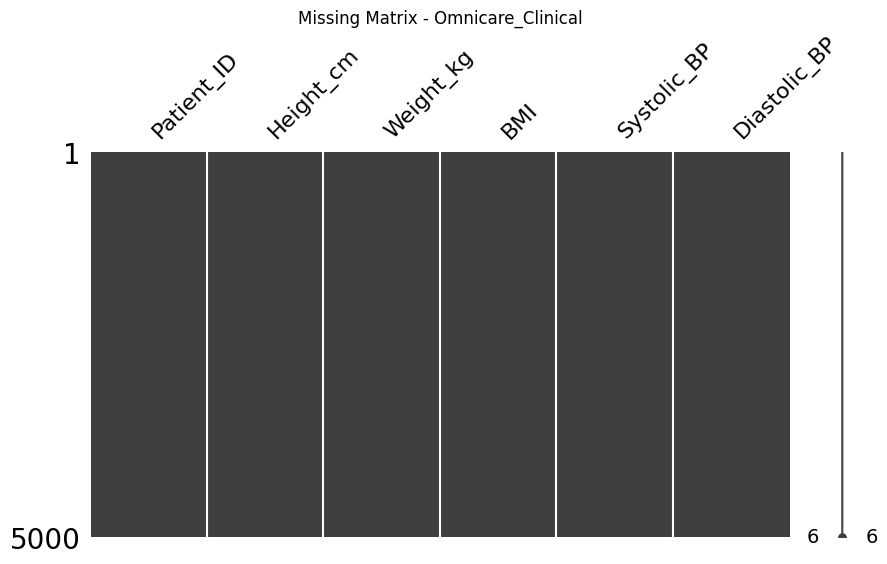

In [22]:
msno.matrix(omnicare_clinical,figsize=(10, 5))
plt.title("Missing Matrix - Omnicare_Clinical")
plt.show()

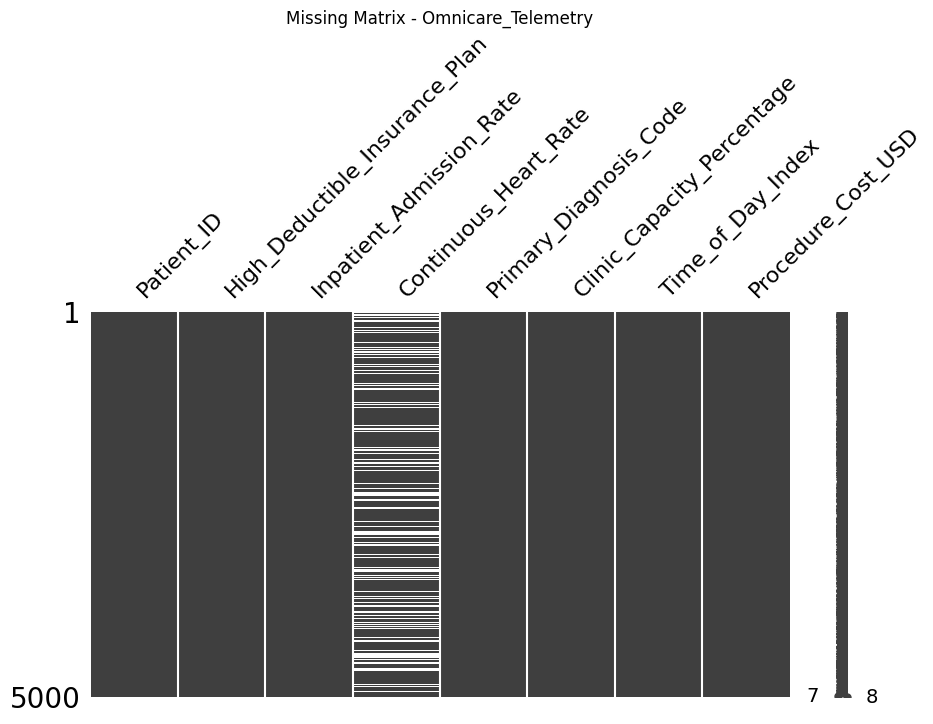

In [23]:
msno.matrix(omnicare_telemetry,figsize=(10, 5))
plt.title("Missing Matrix - Omnicare_Telemetry")
plt.show()

Ans: The graph fit the description of 2.1, which there is a missing in the Continuous_Heart_Rate column. Looking into the overall pattern of the matrix, the missing majorly focused only on the variable of Continous_Heart_Rate while other almost remain full and did not missing in the similar random way, which indicated that it is not the condition of missing completely at random(MCAR). It also does not fall in the category of MAR since the the missing mechanism could not explain by other observed variables. According to the condition, which if these gaps occur entirely because low-income patients systematically refuse to transit telemetry for the purpose of data-plan costs related action, it indicated a systematic action. Which fit the purpose of missing not at random(MNAR), since the missing pattern is depend and relies on the value. In other words, it is related to the social power of the patients, which showcase a connection and impact between the missining pattern and unobserved social and econoimic factor.

The reason that mean imputation would destroy the integrity of the dataset is due to the missing pattern of the missing values. To be specific, when the data is not missing at random, instead it focuses on a group of people with similar characteristics, the use of mean imputation would cover the real discrepancies. Therefore, it would eventually disguise and destroy the relationship between each variables, which impact the robustness and credibility of the analysis.

## 2.2

Ans:
The reason is due to the characteristics of the dataset. To be specific, pd.get_dummies would eventually generate 850 dummy variables, while the patient for the data set each belongs to a specific diagnosis category, thus there would be only 1 dummy has the value of 1 and the rest of the values are zero. However, their sum would always be 1, and at the same time the intercept would also be 1 for each row. For instance, the value of the intercept would always be the sum of the other variables. As a result of that, there would be redundancy and the information are repeated due to the same information provision from both dummy and intercept. While the regression model is mainly relies on the unique and extra information from each row of the variables. Therefore, when the model exists repetead information, it is hard to distinguish whether the explanation derived from the dummy or the intercept, which leads to perfect multicollinearity. Eventually lead to the false identification and the destruction of the regression structure, so does the not working of OLS from the false recognition of coefficient.

## 2.3

In [24]:
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

omnicare_telemetry["Target_Encoded_Diagnosis"] = encoder.fit_transform(omnicare_telemetry[["Primary_Diagnosis_Code"]], omnicare_telemetry["Procedure_Cost_USD"])["Primary_Diagnosis_Code"]

In [25]:
omnicare_telemetry[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head()

,Primary_Diagnosis_Code,Target_Encoded_Diagnosis
0,J86.381,1707.697108
1,M29.789,1792.303198
2,E49.618,1730.334968
3,E66.244,1725.060944
4,J45.553,1801.821085


# Phase 3

In [26]:
final_merge = pd.merge(omnicare_telemetry, omnicare_clinical)

In [27]:
final_merge

,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD,Target_Encoded_Diagnosis,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84,1707.697108,177.5,66.3,21.06,110.0,75.0
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77,1792.303198,167.9,57.5,20.39,115.0,79.0
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19,1730.334968,179.7,57.4,17.77,111.0,77.0
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93,1725.060944,192.8,80.9,21.76,122.0,88.0
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34,1801.821085,166.5,65.7,23.70,138.0,89.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5995,1,0.140,52.2,M96.598,0.58,3.7,1150.29,1714.992854,169.3,72.7,25.39,106.0,76.0
4996,5996,0,0.152,76.0,M63.490,0.68,17.6,1739.46,1739.638804,180.7,56.6,17.34,139.0,100.0
4997,5997,0,0.363,91.0,C64.505,0.77,2.3,1713.14,1715.834832,216.7,99.4,21.16,140.0,96.0
4998,5998,0,0.118,53.5,A23.926,0.55,9.2,1589.11,1759.303097,182.1,77.9,23.48,107.0,83.0


In [28]:
formula = "Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Height_cm + BMI + Systolic_BP + Diastolic_BP"

In [29]:
ols_model = smf.ols(formula=formula, data=final_merge)
ols_model = ols_model.fit()

results=ols_model.summary()
print(results)

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          6.08e-296
Time:                        19:37:52   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

## 3.2

In [30]:
from statsmodels.tools.eval_measures import rmse

In [31]:
y_pred = ols_model.predict(final_merge)
rmse_value = rmse(final_merge["Procedure_Cost_USD"], y_pred)

rmse_value

np.float64(334.79424791117185)

Ans: After running rmse, the value is 334.79, which indicated a huge error comparing to the value of 1200 dollars. In other words, a huge deviation comparing to the supposed predicted average deviation of 334.79 dollars. This pattern showed the drawback of the model due to its uncertainty on the result.

If such dynamic pricing algorithm is deployed, it would create the false cost assumption and related issue due to the huge deviation on the perspective of operational risk and allocation of budget. For instance, the insustianble provision of resources. For the financial risk aspect, it would create problem according to both hospital and patients sides. To be specific, the problem of insufficient of fund, since the undervalue condition of the algorithm would result the hospital generate less revenue from undercharging. At the same time, the deviation also could be overvalue, thus overvalued high-price leading to the reduction in patient and treatment rate. The main regulatory risk would be the compliance problem of the hospital, since incorrect estimation from the algorithm might cause the huge difference between actual charge and estimated charge, which leading to the report from patients due to the exhibit problem of the structure and lead to future regulation suspects.

## 3.3

In [32]:
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

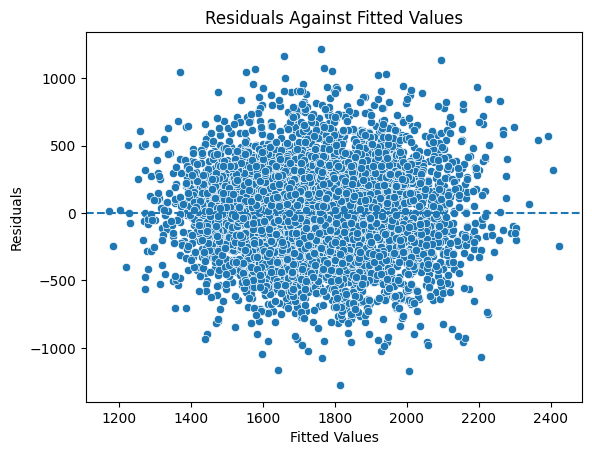

In [33]:
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals Against Fitted Values")
plt.show()

Ans: According to the plot, it did not expand the fan as the fitted values increased. The fluctuation also did not show the relationship of expansion as the predicted procedure cost increases. Therefore,based on the pattern in the plot, such algorithm shown that under peak surge-pricing tiers seems not be unreliable based on the performance of the plot. However, further verification should be needed to check whether heteroscedasticity exist. If there this heteroscedasticity, it indicate a issue of high deviation and less reliable for the peak surge-price tiers condition.

# Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

# P.R.I.M.E. Prompt — Task 4.1: White's Lagrange Multiplier Test for Heteroscedasticity

**Persona:**
You are a senior econometrician and Python data scientist with deep expertise in OLS regression diagnostics, particularly in detecting heteroscedasticity using formal statistical tests.

**Role:**
Your role is to write a complete, executable Python script that performs White's Lagrange Multiplier Test for Heteroscedasticity on an already-fitted OLS model, using the `statsmodels` library.

**Instructions:**
1. Assume the following objects already exist in the environment:
   - `ols_model`: a fitted OLS model produced by `statsmodels.formula.api.smf.ols().fit()`.
   - The OLS formula was: `Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Height_cm + BMI + Systolic_BP + Diastolic_BP`
   - The data source is a merged DataFrame called `final_merge` with 5,000 observations.
2. Import `het_white` from `statsmodels.stats.diagnostic`.
3. Extract the residuals from `ols_model` using `ols_model.resid`.
4. Extract the exogenous variables (design matrix including the constant) from `ols_model` using `ols_model.model.exog`.
5. Call `het_white(resid, exog)` and unpack all four return values: the LM test statistic, the LM p-value, the F-statistic, and the F p-value.
6. Print the LM test statistic and the LM p-value clearly labeled.
7. At the end, print a concluding sentence: if the LM p-value < 0.05, state that we reject the null hypothesis of homoscedasticity (heteroscedasticity is detected); otherwise, state that we fail to reject the null hypothesis of homoscedasticity.
8. Use a significance level of α = 0.05 for the conclusion.

**Meaning:**
White's test is used to determine whether the variance of the residuals in an OLS regression is constant (homoscedasticity) or varies systematically with the independent variables (heteroscedasticity). If heteroscedasticity is present, standard OLS standard errors are biased, leading to unreliable hypothesis tests and confidence intervals. The null hypothesis (H₀) is that the error variances are homoscedastic.

**Evaluation:**
- The script must use `statsmodels.stats.diagnostic.het_white` exactly.
- The script must be self-contained (aside from the pre-existing `ols_model` object) and run without errors in a Google Colab cell.
- The output must clearly display the LM test statistic, the LM p-value, and a plain-English concluding sentence about whether homoscedasticity is rejected at the 0.05 level.

In [34]:
from statsmodels.stats.diagnostic import het_white

# Extract residuals and exogenous variables from the fitted OLS model
resid = ols_model.resid
exog = ols_model.model.exog

# Run White's Lagrange Multiplier Test
lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(resid, exog)

print(f"White's LM Test Statistic: {lm_stat:.4f}")
print(f"White's LM Test P-Value:   {lm_pvalue:.4f}")
print(f"F-Statistic:               {f_stat:.4f}")
print(f"F-Test P-Value:            {f_pvalue:.4f}")
print()

alpha = 0.05
if lm_pvalue < alpha:
    print(f"Conclusion: Since the LM p-value ({lm_pvalue:.4f}) < {alpha}, "
          f"we reject the null hypothesis of homoscedasticity. "
          f"Heteroscedasticity is statistically detected in the model residuals.")
else:
    print(f"Conclusion: Since the LM p-value ({lm_pvalue:.4f}) >= {alpha}, "
          f"we fail to reject the null hypothesis of homoscedasticity. "
          f"There is no statistically significant evidence of heteroscedasticity.")

White's LM Test Statistic: 186.4282
White's LM Test P-Value:   0.0000
F-Statistic:               5.4930
F-Test P-Value:            0.0000

Conclusion: Since the LM p-value (0.0000) < 0.05, we reject the null hypothesis of homoscedasticity. Heteroscedasticity is statistically detected in the model residuals.
